# Example: SERNAGEOMIN geological map → buffered point cloud for 3D modelling

This notebook shows the complete `geomodeltools` workflow on real public data. It turns the geological units polygon layer of a 1:100,000 map into labelled 3D points that you can use to build an implicit geological model (for example in Leapfrog).

1. **Get the data.** The notebook downloads the SERNAGEOMIN *Carrizalillo – El Tofo* map (Mapa M201) from this repo's `sample-data-sernageomin` release and unzips it.
2. **Crop.** It clips the geological units polygons (`GB_UNIDAD_GEO_P`) to an area of interest (AOI) box.
3. **Reproject.** It converts from SIRGAS 2000 / UTM 19S (EPSG:31994, the source CRS) to **PSAD56 / UTM 19S (EPSG:24879)**, the package default.
4. **Clean.** `clean_polygon_geometries` fixes invalid shapes and splits multipolygons into single parts.
5. **Buffer to points.** `bufferize_2d_polygons(..., map_scale=100_000, adaptive=True)` builds inward buffers, turns them into points and labels each point with its unit code (`CODIGO`). The map scale sets every spacing, and the adaptive mode gives narrow polygons points sized to their own width.
6. **Add elevation (optional).** `add_z_from_opentopography` samples a DEM. This step needs an OpenTopography API key (see the README).
7. **Export.** It writes a GeoPackage, CSVs and, if PyVista is installed, a VTK point cloud to `notebooks/outputs/`.

**Reproducibility.** Every input is downloaded by the notebook and every parameter is set in the *Parameters* cell. Re-running from a clean clone gives the same outputs (the DEM step also needs an API key). The data and outputs are git-ignored.

**Data source and copyright.** SERNAGEOMIN (Servicio Nacional de Geología y Minería, Chile), *Geología del Área Carrizalillo – El Tofo, Región de Coquimbo*, Carta Geológica de Chile, Serie Geología Básica, 1:100,000. The data is mirrored in this repo's release only as sample data.

**Requirements.** `pip install -e .` from the repo root, plus `matplotlib` for the plots. `pyvista` is optional and only needed for the `.vtp` export.


In [1]:
import os
import sys
import urllib.request
import warnings
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pyproj
from shapely.geometry import box

# Locate the repo root whether the notebook is run from <repo>/notebooks/ or from <repo>/.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), "Run this notebook from the repo root or from notebooks/."

# Use the package from this checkout if it isn't pip-installed.
_SRC_DIR = REPO_ROOT / "src"
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

from geomodeltools import (
    add_z_from_opentopography,
    bufferize_2d_polygons,
    clean_polygon_geometries,
)

print("Repo root:", REPO_ROOT)
print("geopandas", gpd.__version__, "| pyproj", pyproj.__version__, "| PROJ", pyproj.proj_version_str)

Repo root: /home/user/geomodeltools
geopandas 1.2.0 | pyproj 3.7.2 | PROJ 9.5.1


## Parameters

Every setting that affects the outputs is in this cell.

### Area of interest

The AOI started as a Google Earth screenshot of the Domeyko – Palo Blanco – Arenillas – El Trapiche area. Its edges were read off the lat/long graticule (±0.5′). That box, 71°12.4′–70°49.4′ W by 28°49′–29°31′ S, extends east of the M201 map sheet, which only covers **71°40′–71°00′ W by 29°00′–29°30′ S**.

So the box keeps its width of 0.383° of longitude, about 37 km, and is moved west until its east edge sits on the sheet's east edge at 71°00′ W. Its height is trimmed to the sheet's full height, 29°00′–29°30′ S. The result is roughly **37 km × 55 km**, covering Arenillas, Palo Blanco (west) and El Trapiche.

### Settings from the map scale

At 1:100,000, 1 mm on paper is 100 m on the ground. Contacts are drawn to about 0.5 mm, so they are only accurate to about **50 m**. Anything finer than that adds points without adding information.

Passing `map_scale=MAP_SCALE` to `bufferize_2d_polygons` sets every spacing from this precision, as the table below shows. Any of them can still be passed explicitly to override it.

| Parameter | On paper | At 1:100,000 | Why |
|---|---|---|---|
| `simplify_tolerance` | 0.25 mm | 25 m | Half the line precision, so the shapes don't visibly change. It cuts the source vertices about 8× and makes buffering about 4× faster. |
| `segment_max_length` | 1 mm | 100 m | Point spacing along each ring. |
| `increments`, `repeats` | (0.5, 2) mm, (2, 5) | (50, 200) m, (2, 5) | Rings at −50 and −100 m near each contact, where the boundary matters most, then every 200 m out to −1,100 m, then every 400 m until each polygon has shrunk away. |
| `narrow_half_width` | 1 mm | 100 m | Adaptive mode: polygons narrower than this get a centreline. |
| `min_half_width` | 0.25 mm | 25 m | Adaptive mode: polygons narrower than this get only the centreline, with no extra ring. They are effectively lines at this scale. |

**Why use the adaptive mode.** With fixed distances, every polygon less than about 100 m wide vanishes at the first −50 m ring. In this area that is 427 of 1,569 polygons (27%), so those units would be **missing from the model**. Many more get just one ring, or a ring that breaks at narrow necks. `adaptive=True` measures each polygon's mean half-width, `h = area / perimeter`, and adds:

- **a centreline** (an approximate medial axis) when `h` < `narrow_half_width`. It stays continuous through the necks where buffer rings break.
- **one ring at 0.4 × `h`** when the fixed rings give at most one ring and `h` ≥ `min_half_width`.
- **a single interior point** as a last resort, so no polygon is left without points.

Each point gets a `point_source` column (`ring`, `adaptive_ring`, `centreline` or `fallback_point`) so you can see where it came from.

**Your own choice: interior spacing.** The ring spacing further in sets the total number of points and should match your model's resolution. To change it, pass `increments` and `repeats` explicitly, for example `(50, 400)` with `(2, 3)` for a coarser model.


In [2]:
# --- Data -------------------------------------------------------------------
RELEASE_URL = "https://github.com/ramaguirre/geomodeltools/releases/download/sample-data-sernageomin"
ZIP_NAME = "M201_Geologia_Area_CarrizalilloElTofo_GIS.zip"
DATA_DIR = REPO_ROOT / "sample_data" / "sernageomin"          # git-ignored
EXTRACT_DIR = DATA_DIR / "M201"
GDB_PATH = EXTRACT_DIR / "M201_CarrizalilloElTofo.gdb"
UNITS_LAYER = "GB_UNIDAD_GEO_P"   # geological unit polygons
MAP_FRAME_LAYER = "MD_MAPA"       # map sheet outline, used to check the AOI
UNIT_COL = "CODIGO"               # unit code carried onto the points

# --- Area of interest (WGS84 degrees) -----------------------------------------
AOI_WGS84 = dict(minx=-71.383, miny=-29.500, maxx=-71.000, maxy=-29.000)

# --- CRS ------------------------------------------------------------------------
OUT_CRS = "EPSG:24879"  # PSAD56 / UTM zone 19S

# --- Buffering (see table above) -----------------------------------------------------
MAP_SCALE = 100_000  # 1:100,000; sets every spacing
ADAPTIVE = True      # width-based points for narrow polygons

# --- DEM (optional step) ----------------------------------------------------------------
DEM_TYPE = "AW3D30"
DEM_MARGIN_M = 1000

# --- Outputs ----------------------------------------------------------------------------
OUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "m201_example"  # git-ignored
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Download and unzip the map package

This step is skipped if the files are already there. It needs no login, because release assets on a public repo can be downloaded directly. The zip is about 54 MB.

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
zip_path = DATA_DIR / ZIP_NAME

if not zip_path.exists():
    print(f"Downloading {ZIP_NAME} ...")
    urllib.request.urlretrieve(f"{RELEASE_URL}/{ZIP_NAME}", zip_path)
print(f"{zip_path.name}: {zip_path.stat().st_size / 1e6:.1f} MB")

if not GDB_PATH.exists():
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(EXTRACT_DIR)
print("Geodatabase:", GDB_PATH.relative_to(REPO_ROOT))

M201_Geologia_Area_CarrizalilloElTofo_GIS.zip: 53.7 MB
Geodatabase: sample_data/sernageomin/M201/M201_CarrizalilloElTofo.gdb


## 2. Load the units layer and check the AOI

Fiona/pyogrio can print harmless warnings about ring orientation when it reads File Geodatabase multipolygons, so these are silenced. `clean_polygon_geometries` fixes the geometry in step 4 anyway.

In [4]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    units = gpd.read_file(GDB_PATH, layer=UNITS_LAYER)
    map_frame = gpd.read_file(GDB_PATH, layer=MAP_FRAME_LAYER)

print(f"{UNITS_LAYER}: {len(units)} polygons, {units[UNIT_COL].nunique()} units, CRS {units.crs.to_string()}")

aoi_wgs84 = gpd.GeoDataFrame(geometry=[box(**AOI_WGS84)], crs="EPSG:4326")
aoi_src = aoi_wgs84.to_crs(units.crs)

frame = map_frame.union_all() if hasattr(map_frame, "union_all") else map_frame.unary_union
inside = aoi_src.geometry.iloc[0].difference(frame.buffer(1)).area / aoi_src.area.iloc[0]
print("Map sheet (WGS84):", map_frame.to_crs(4326).total_bounds.round(4))
print(f"AOI outside map sheet: {inside:.2%}")
assert inside < 0.01, "The AOI should lie inside the map sheet."


GB_UNIDAD_GEO_P: 2162 polygons, 59 units, CRS EPSG:31994
Map sheet (WGS84): [-71.6667 -29.5    -71.     -29.    ]
AOI outside map sheet: 0.02%


## 3. Crop and reproject to PSAD56 / UTM 19S

The polygons are clipped in the source CRS, so they are cut along the true AOI edges, and then reprojected.

**Watch the datum change.** The source CRS is SIRGAS 1995 / UTM 19S. PROJ has no direct SIRGAS 1995 → PSAD56 transformation, so `to_crs(OUT_CRS)` quietly falls back to a *"Ballpark geographic offset"*. That applies **no datum shift**, which puts every point about 460 m from where it belongs (the cell below measures it). To avoid it, the notebook goes through WGS 84:

1. SIRGAS 1995 → WGS 84. The two agree to within about 1 m, and EPSG treats this as a null transformation.
2. WGS 84 → PSAD56 using **EPSG "PSAD56 to WGS 84 (16)"**. This is a 3-parameter Helmert shift (dX = 328, dY = −340, dZ = 329 m) valid onshore in Chile between 26°S and 36°S, with an accuracy of about 17 m, well within the map's roughly 50 m precision.

The cell below prints the transformation it uses and stops with an error if it is ever a ballpark one. The package's DEM step (`add_z_from_opentopography`) converts between EPSG:24879 and WGS 84, so it uses the same correct transformation.

In [5]:
# Reference: EPSG "PSAD56 to WGS 84 (16)" written out as an explicit PROJ pipeline.
PSAD56_16 = pyproj.Transformer.from_pipeline(
    "+proj=pipeline +step +proj=unitconvert +xy_in=deg +xy_out=rad "
    "+step +proj=push +v_3 +step +proj=cart +ellps=WGS84 "
    "+step +proj=helmert +x=328 +y=-340 +z=329 "
    "+step +inv +proj=cart +ellps=intl +step +proj=pop +v_3 "
    "+step +proj=utm +zone=19 +south +ellps=intl"
)

def _check_route(src_crs, lon=-71.2, lat=-29.25):
    # Check that src_crs -> WGS 84 -> OUT_CRS agrees with the reference within 1 m.
    p_src = gpd.GeoSeries(gpd.points_from_xy([lon], [lat]), crs="EPSG:4326").to_crs(src_crs)
    got = p_src.to_crs("EPSG:4326").to_crs(OUT_CRS).iloc[0]
    ex, ey = PSAD56_16.transform(lon, lat)
    return ((got.x - ex) ** 2 + (got.y - ey) ** 2) ** 0.5

direct = gpd.GeoSeries(gpd.points_from_xy([-71.2], [-29.25]), crs="EPSG:4326").to_crs(units.crs).to_crs(OUT_CRS).iloc[0]
ex, ey = PSAD56_16.transform(-71.2, -29.25)
print(f"Direct to_crs error (ballpark, no datum shift): {((direct.x - ex)**2 + (direct.y - ey)**2) ** 0.5:.0f} m")
err = _check_route(units.crs)
print(f"Via WGS 84 error: {err:.3f} m")
assert err < 1, "SIRGAS 1995 -> WGS 84 -> PSAD56 did not use 'PSAD56 to WGS 84 (16)' - check the PROJ install."

cropped = gpd.clip(units, aoi_src).to_crs("EPSG:4326").to_crs(OUT_CRS)
aoi_out = aoi_src.to_crs("EPSG:4326").to_crs(OUT_CRS)
print(f"Cropped: {len(cropped)} features, {cropped[UNIT_COL].nunique()} units")
print("Bounds (EPSG:24879):", cropped.total_bounds.round(0))

Direct to_crs error (ballpark, no datum shift): 464 m
Via WGS 84 error: 0.000 m


Cropped: 1564 features, 56 units
Bounds (EPSG:24879): [ 268044. 6734721.  306308. 6790741.]


## 4. Clean

`clean_polygon_geometries` fixes any invalid shapes, drops empty ones and orients the rings consistently. Multipolygons are then split into single parts so each part is buffered on its own. Simplifying to map precision happens inside `bufferize_2d_polygons` (`simplify_tolerance`, derived from `map_scale`).

In [6]:
polys = clean_polygon_geometries(cropped)
polys = polys[polys.area > 0].explode(ignore_index=True)

half_width = polys.area / polys.length
print(f"Polygons: {len(polys)}, area {polys.area.sum() / 1e6:.0f} km2, vertices {int(polys.geometry.count_coordinates().sum()):,}")
print(f"Mean half-width (area / perimeter) percentiles 10/50/90: {half_width.quantile([.1, .5, .9]).round(0).tolist()} m")
print(f"Narrower than {MAP_SCALE / 1000:.0f} m half-width (adaptive centreline): {(half_width < MAP_SCALE / 1000).sum()}")

Pre-cleaning polygon geometries: fixing invalid shapes, keeping polygonal parts, and normalizing ring orientation.
Pre-clean complete: invalid geometries 0 -> 0; dropped 0 empty/non-polygon features.
Polygons: 1569, area 1945 km2, vertices 406,088
Mean half-width (area / perimeter) percentiles 10/50/90: [15.0, 44.0, 140.0] m
Narrower than 100 m half-width (adaptive centreline): 1297


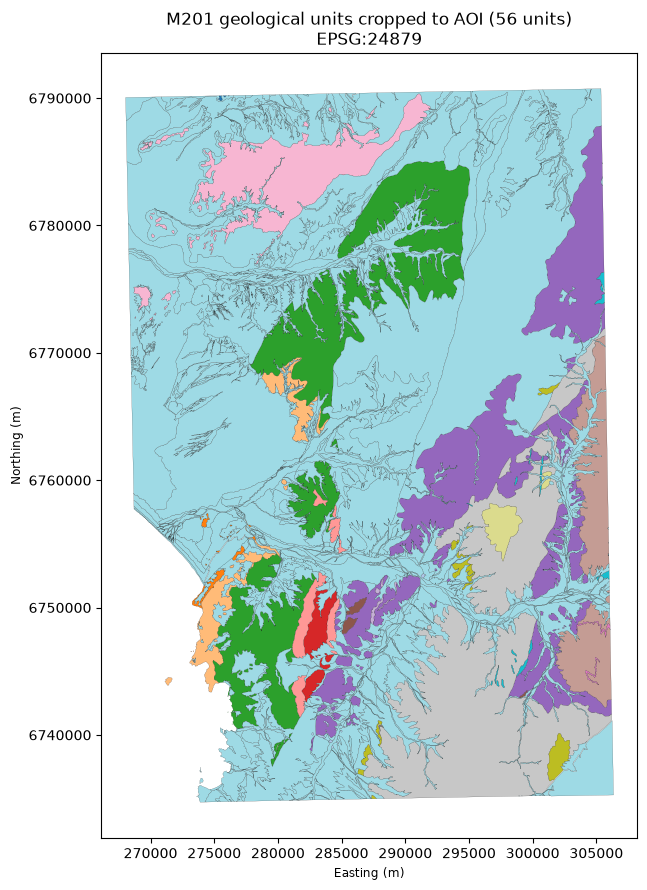

In [7]:
fig, ax = plt.subplots(figsize=(7, 9))
polys.plot(column=UNIT_COL, ax=ax, cmap="tab20", linewidth=0.1, edgecolor="k", categorical=True)
ax.set_title(f"M201 geological units cropped to AOI ({polys[UNIT_COL].nunique()} units)\nEPSG:24879")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
plt.tight_layout()
plt.show()

## 5. Inward buffers to points

The same polygons are buffered twice: once with fixed distances only, and once with `adaptive=True`. Comparing the two shows what the adaptive mode adds. `level_col_or_z=0` gives every point z = 0 for now; step 6 replaces it with DEM elevations.

In [8]:
common = dict(feature_cols=[UNIT_COL], level_col_or_z=0, map_scale=MAP_SCALE, return_polydata=False, verbose=False)

points_fixed = bufferize_2d_polygons(polys, adaptive=False, **common)
points = bufferize_2d_polygons(polys, adaptive=ADAPTIVE, **common)


def n_polygons_without_points(pts):
    hit = gpd.sjoin(polys[["geometry"]].reset_index(), pts[["geometry"]], predicate="intersects")["index"].nunique()
    return len(polys) - hit


print(f"Fixed rings only: {len(points_fixed):,} points, {n_polygons_without_points(points_fixed)} polygons without points")
print(f"Adaptive:         {len(points):,} points, {n_polygons_without_points(points)} polygons without points")
if "point_source" in points:
    display(points["point_source"].value_counts().rename("n_points").to_frame().T)

Fixed rings only: 156,039 points, 430 polygons without points


Adaptive:         206,524 points, 0 polygons without points


point_source,ring,centreline,adaptive_ring,fallback_point
n_points,156039,40215,10269,1


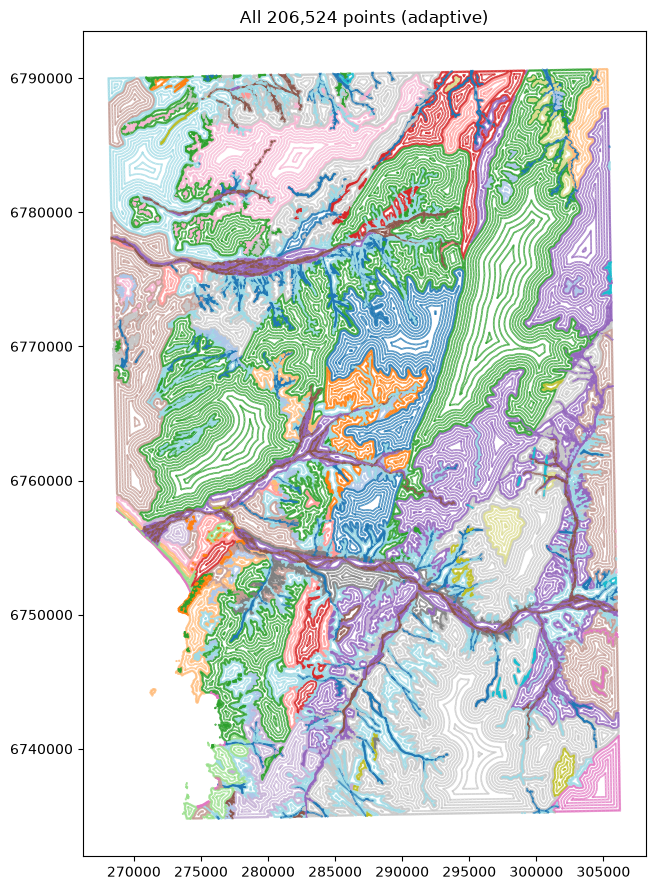

In [9]:
# Same colour for the same unit in every panel
codes = sorted(polys[UNIT_COL].unique())
cmap = plt.get_cmap("tab20")
unit_colour = {c: cmap(i % 20) for i, c in enumerate(codes)}

fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(points.x, points.y, s=0.1, c=points[UNIT_COL].map(unit_colour).tolist())
ax.set_title(f"All {len(points):,} points (adaptive)")
ax.set_aspect("equal")
ax.ticklabel_format(style="plain")
plt.tight_layout()
plt.show()

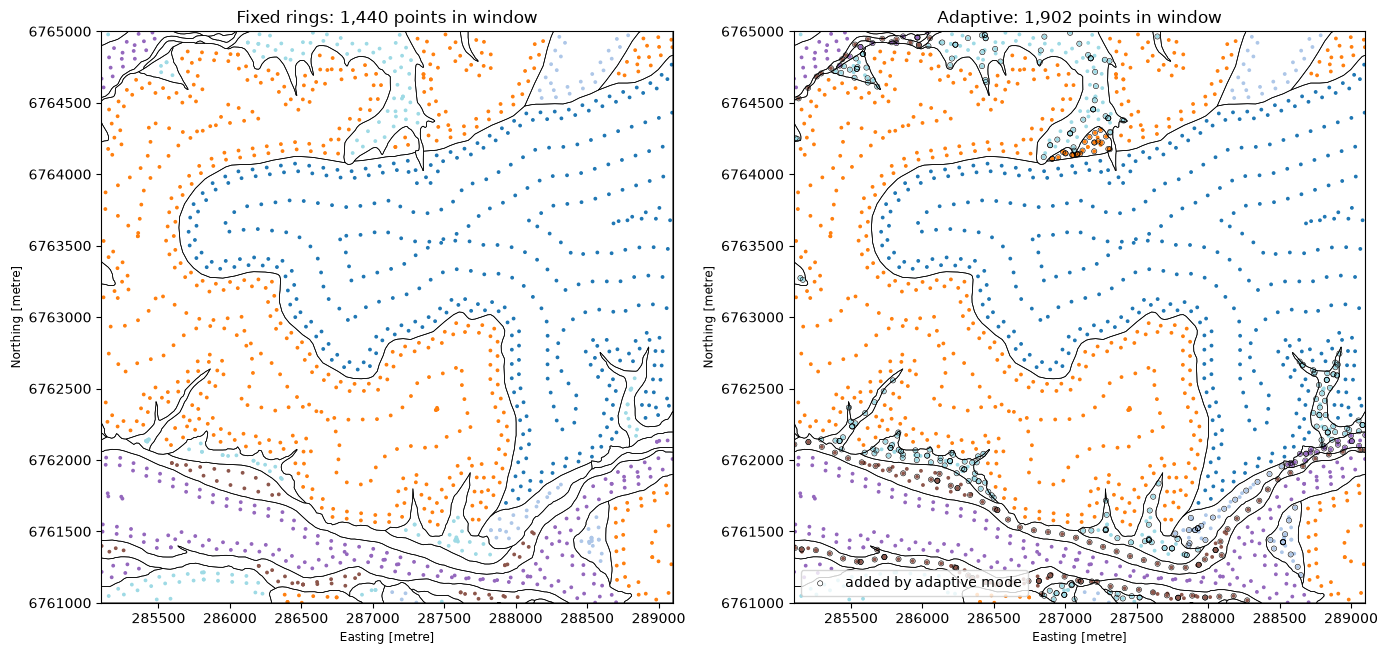

In [10]:
# 4 x 4 km window with many narrow units: fixed rings vs adaptive
cx, cy = 287100, 6763000
win = box(cx - 2000, cy - 2000, cx + 2000, cy + 2000)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
for ax, pts, title in [(axes[0], points_fixed, "Fixed rings"), (axes[1], points, "Adaptive")]:
    polys.clip(win).boundary.plot(ax=ax, color="k", linewidth=0.5)
    p = pts.clip(win)
    ax.scatter(p.x, p.y, s=3, c=p[UNIT_COL].map(unit_colour).tolist())
    if "point_source" in p:
        cl = p[p["point_source"] != "ring"]
        ax.scatter(cl.x, cl.y, s=14, facecolors="none", edgecolors="k", linewidths=0.4,
                   label="added by adaptive mode")
        ax.legend(loc="lower left")
    ax.set_title(f"{title}: {len(p):,} points in window")
    ax.set_xlim(win.bounds[0], win.bounds[2])
    ax.set_ylim(win.bounds[1], win.bounds[3])
    ax.set_aspect("equal")
    ax.ticklabel_format(style="plain")
plt.tight_layout()
plt.show()

## 6. Elevation from a DEM (optional)

This step needs an OpenTopography API key, set in the `OPENTOPOGRAPHY_API_KEY` environment variable (see the README). The DEM is saved as a GeoTIFF in EPSG:24879 and reused on later runs. If there is no key and no cached DEM, the step is skipped and the points keep z = 0.

In [11]:
dem_path = OUT_DIR / f"dem_{DEM_TYPE}_24879.tif"

if dem_path.exists() or os.environ.get("OPENTOPOGRAPHY_API_KEY"):
    points_z, dem_path = add_z_from_opentopography(
        points,
        out_tiff_path=dem_path,
        crs=OUT_CRS,
        margin_m=DEM_MARGIN_M,
        demtype=DEM_TYPE,
        keep_geometry_old=False,
    )
    points_z["z"] = points_z.geometry.z
    print(f"z range: {points_z['z'].min():.0f} to {points_z['z'].max():.0f} m, "
          f"{points_z['z'].isna().sum()} points without DEM value")
else:
    points_z = None
    print("No OPENTOPOGRAPHY_API_KEY and no cached DEM: skipping elevation step (points keep z = 0).")

No OPENTOPOGRAPHY_API_KEY and no cached DEM: skipping elevation step (points keep z = 0).


## 7. Export

| File | Contents |
|---|---|
| `m201_aoi_units_24879.gpkg` | Layer `units`: the cropped, cleaned polygons. Layer `aoi`: the AOI box. Both in EPSG:24879. |
| `m201_aoi_points_24879.csv` | `x, y, z, CODIGO, point_source`, with z = 0. |
| `m201_aoi_points_z_24879.csv` | The same points with DEM elevations. Only written if step 6 ran. |
| `m201_aoi_points_24879.vtp` | PyVista point cloud with `CODIGO` as point data. Only written if PyVista is installed. |


In [12]:
gpkg_path = OUT_DIR / "m201_aoi_units_24879.gpkg"
polys.to_file(gpkg_path, layer="units", driver="GPKG")
aoi_out.to_file(gpkg_path, layer="aoi", driver="GPKG")

cols = ["x", "y", "z", UNIT_COL] + (["point_source"] if "point_source" in points else [])
points[cols].to_csv(OUT_DIR / "m201_aoi_points_24879.csv", index=False)
if points_z is not None:
    points_z[cols].to_csv(OUT_DIR / "m201_aoi_points_z_24879.csv", index=False)

try:
    import pyvista as pv

    src = points_z if points_z is not None else points
    cloud = pv.PolyData(src[["x", "y", "z"]].to_numpy(dtype=float))
    cloud.point_data[UNIT_COL] = src[UNIT_COL].astype(str).to_numpy()
    cloud.save(OUT_DIR / "m201_aoi_points_24879.vtp")
except ImportError:
    print("pyvista not installed: skipping .vtp export")

for f in sorted(OUT_DIR.iterdir()):
    print(f"{f.name:40s} {f.stat().st_size / 1e6:7.2f} MB")

m201_aoi_points_24879.csv                  11.07 MB
m201_aoi_points_24879.vtp                   4.38 MB
m201_aoi_units_24879.gpkg                   7.95 MB
